In [2]:
##Libraries to run the tools##
# libraries
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

In [3]:
df = pd.read_csv("test-angle-equil9.dat", sep='\s+', names= ['angle','E2E'])

In [4]:
df

,angle,E2E
0,68.827570,44.636267
1,157.215536,116.798675
2,120.123972,108.028363
3,75.190594,48.342862
4,161.134231,79.178497
...,...,...
63432,75.172865,44.289741
63433,51.538500,30.883722
63434,59.789612,46.522576
63435,57.609426,44.306191


In [5]:
##ax = sns.histplot(df["E2E"])

<Figure size 1000x600 with 0 Axes>

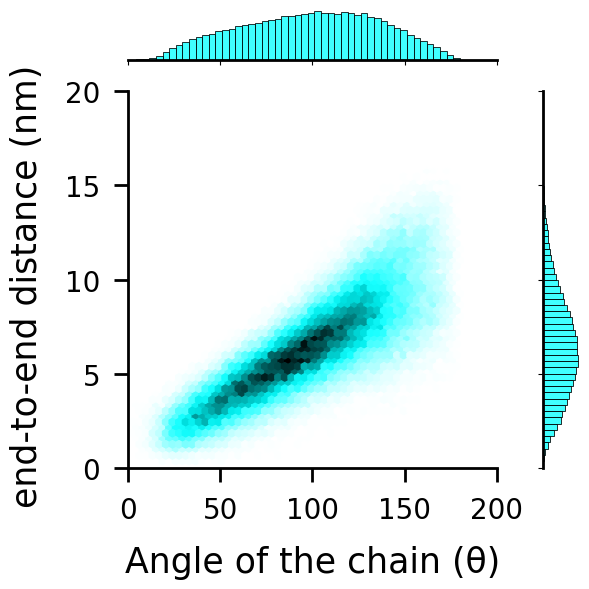

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt
##df = sns.load_dataset('iris')

## final plot of SASA CG & AA data ##
fig = plt.figure(1034, figsize=(10,6))
from pylab import*
rc('axes', linewidth=2.0)

df_clean = df.replace([np.inf, -np.inf], np.nan).dropna(subset=["angle", "E2E"])
g=sns.jointplot(x=df_clean["angle"], y=df_clean["E2E"]*0.10, kind='hex', color='cyan', marginal_kws=dict(bins=50, fill=True))

# Get hexbin object and extract density data
hb = g.ax_joint.collections[0]
verts = hb.get_offsets()  # center of each hex
counts = hb.get_array()   # density value at each hex

# Save density data to a CSV file
density_data = pd.DataFrame({
    "angle": verts[:, 0],
    "E2E": verts[:, 1],
    "density": counts
})
density_data.to_csv("hex_density_data.csv", index=False)

##change the axis lable, fontsize and lable size of the plot## 
plt.ylabel('end-to-end distance (nm) ', fontsize=25, labelpad=15, fontname='sans-serif')
plt.xlabel('Angle of the chain (\u03B8)', fontsize=25, labelpad=15, fontname='sans-serif')
plt.ylim([0.0, 20.0])
plt.yticks(np.arange(0, 20.01, 5 ), fontsize=40, fontname='sans-serif')
plt.xlim([0.0, 200])
plt.xticks(np.arange(0.0, 200.01, 50), fontsize=40, fontname='sans-serif')
##plt.legend(fontsize=15, bbox_to_anchor=(0.95,0.95), loc='upper right', edgecolor='white')
plt.tick_params(axis='both', which='major', labelsize=20, direction='out', length=10, pad=10, bottom='bool', left='bool', width=2)
# Remove white space, save and show
plt.tight_layout()
plt.savefig('E2E-angle-pluronic-test.png', dpi=400)
plt.show()

<Figure size 1000x600 with 0 Axes>

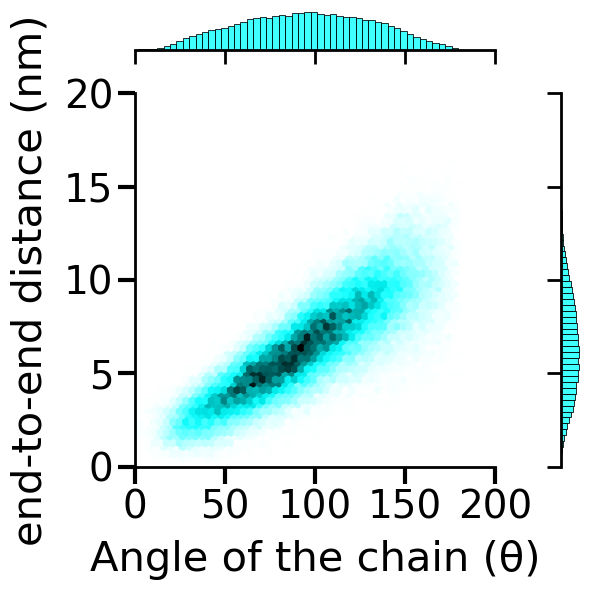

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pylab import rc

## final plot of SASA CG & AA data ##
fig = plt.figure(1034, figsize=(10,6))
rc('axes', linewidth=2.0)

df_clean = df.replace([np.inf, -np.inf], np.nan).dropna(subset=["angle", "E2E"])
g = sns.jointplot(
    x=df_clean["angle"],
    y=df_clean["E2E"] * 0.10,
    kind='hex',
    color='cyan',
    marginal_kws=dict(bins=50, fill=True)
)

# Get hexbin object and extract density data
hb = g.ax_joint.collections[0]
verts = hb.get_offsets()  # center of each hex
counts = hb.get_array()   # density value at each hex

# Save density data to a CSV file
density_data = pd.DataFrame({
    "angle": verts[:, 0],
    "E2E": verts[:, 1],
    "density": counts
})
density_data.to_csv("hex_density_data.csv", index=False)

## Change the axis label, fontsize, and tick size ##
g.ax_joint.set_xlabel('Angle of the chain (θ)', fontsize=30, labelpad=10, fontname='sans-serif')
g.ax_joint.set_ylabel('end-to-end distance (nm)', fontsize=30, labelpad=10, fontname='sans-serif')

# Axis limits
g.ax_joint.set_xlim([0.0, 200])
g.ax_joint.set_ylim([0.0, 20.0])

# Tick labels bigger
g.ax_joint.set_xticks(np.arange(0, 200.01, 50))
g.ax_joint.set_yticks(np.arange(0, 20.01, 5))
g.ax_joint.tick_params(axis='both', which='major', labelsize=28, direction='out', length=12, width=3)

# Make marginal histograms’ ticks bigger too
g.ax_marg_x.tick_params(axis='x', labelsize=28, direction='out', length=10, width=2)
g.ax_marg_y.tick_params(axis='y', labelsize=28, direction='out', length=10, width=2)

plt.tight_layout()
plt.savefig('Figure7D.png', dpi=400)
plt.show()